# 📊 Análise Exploratória de Dados (EDA) - Telco Churn

O objetivo desta análise rápida é entender a distribuição da variável alvo (`Churn`) e identificar as principais *features* que impulsionam o cancelamento de clientes, embasando as decisões de engenharia de features do nosso pipeline.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Carregando os dados brutos
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Convertendo TotalCharges para numérico (tratando espaços vazios)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].replace(' ', ''), errors='coerce')

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 1. Distribuição da Variável Alvo (Churn)
Vamos verificar o balanceamento das classes.

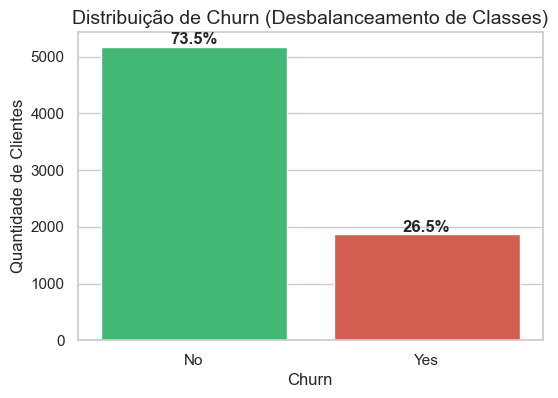

In [6]:
plt.figure(figsize=(6, 4))
# Correção: Adicionado hue='Churn' e legend=False
ax = sns.countplot(data=df, x='Churn', hue='Churn', palette=['#2ecc71', '#e74c3c'], legend=False)
plt.title('Distribuição de Churn (Desbalanceamento de Classes)', fontsize=14)
plt.ylabel('Quantidade de Clientes')

# Adicionando as porcentagens
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height() + 50
    ax.annotate(percentage, (x, y), ha='center', fontweight='bold')

plt.show()

### 2. Impacto do Tipo de Contrato no Churn
Contratos mensais geram mais cancelamentos?

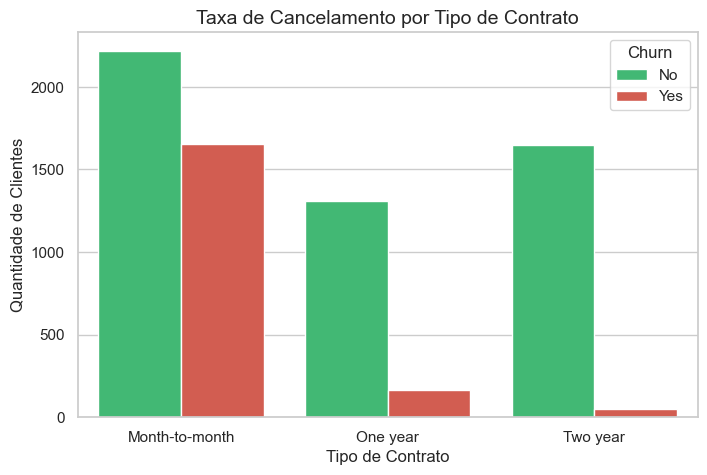

In [7]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Contract', hue='Churn', palette=['#2ecc71', '#e74c3c'])
plt.title('Taxa de Cancelamento por Tipo de Contrato', fontsize=14)
plt.xlabel('Tipo de Contrato')
plt.ylabel('Quantidade de Clientes')
plt.show()

### 3. Relação entre Cobrança Mensal e Churn
Clientes que pagam mais têm maior probabilidade de cancelar?

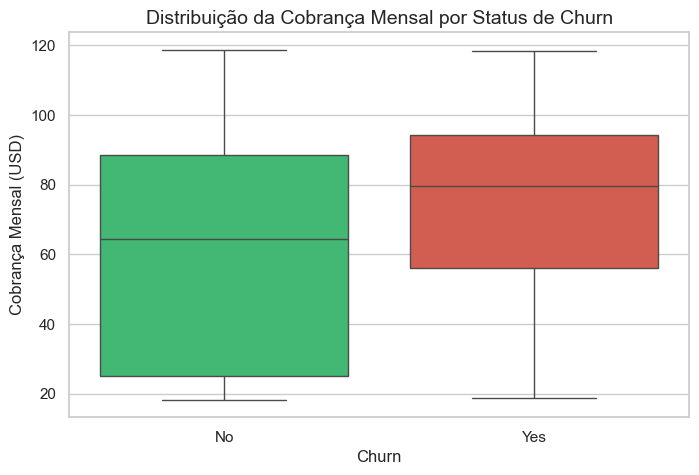

In [8]:
plt.figure(figsize=(8, 5))
# Correção: Adicionado hue='Churn' e legend=False
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', hue='Churn', palette=['#2ecc71', '#e74c3c'], legend=False)
plt.title('Distribuição da Cobrança Mensal por Status de Churn', fontsize=14)
plt.xlabel('Churn')
plt.ylabel('Cobrança Mensal (USD)')
plt.show()

### 📌 Conclusões e Decisões de Engenharia

**1. Desbalanceamento e Métrica de Avaliação:**
A análise revelou um claro desbalanceamento de classes, com apenas 26.5% dos clientes na classe positiva (Churn). Por isso, no treinamento do modelo, optamos por utilizar o parâmetro `scale_pos_weight` no XGBoost e priorizar a métrica de **Recall**. No contexto de negócios de Telecom, o custo de um Falso Negativo (não prever que um cliente vai cancelar) é significativamente maior do que o custo de uma ação de retenção preventiva (Falso Positivo).

**2. Padrões Comportamentais:**
Fica evidente que clientes com contratos mensais (`Month-to-month`) e com faturas mensais mais altas (`MonthlyCharges`) apresentam uma propensão muito maior ao cancelamento. Essas variáveis demonstraram alto poder preditivo, justificando a escolha de um modelo baseado em árvores (XGBoost) capaz de capturar essas relações não-lineares sem a necessidade de transformações complexas nas *features* numéricas.